# Feature Importance

Which inputs the final model relies on. **Permutation importance**: shuffle one feature at a time and measure how much
the error grows. It uses the final model's seed-42 member on the seed-42 validation split — rows that member never
trained on. (The averaged model is not used here: the other seeds trained on some of these rows.)
The figure is saved to `visualizations/feature_importance.png`.

## 1. Setup

In [1]:
import sys, pathlib, warnings
ROOT = next((p for p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents) if (p / 'src' / 'config.py').exists()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the project folder (the one that contains src/).')
sys.path.insert(0, str(ROOT))   # project root -> `import src`, whatever the working folder
warnings.filterwarnings('ignore')
import pandas as pd
pd.set_option('display.float_format', '{:,.2f}'.format)
from sklearn.inspection import permutation_importance
from src import config
from src.preprocessing import prepare_data
from src.prediction import load_final
from src.plotting import plot_importance

## 2. Load the final model and the seed-42 data

In [2]:
final = load_final()   # run final_selection.ipynb first
member = final.member(config.RANDOM_STATE)
data = prepare_data(seed=config.RANDOM_STATE)
assert list(data['feature_names']) == member['feature_names']
print(f"{final.name}: seed-{member['seed']} member, scored on {len(data['X_val'])} validation listings")

Gradient Boosting: seed-42 member, scored on 710 validation listings


## 3. Permutation importance

,RMSE increase (Rs)
logsize_x_Mumbai,"17,191.40"
log_size,"16,655.04"
Point_of_Contact_Contact_Agent,"8,362.64"
Bathroom,"7,418.91"
City_Mumbai,"7,188.80"
log_bath,"5,412.88"
locality_target_enc,"4,421.42"
Point_of_Contact_Contact_Owner,"3,262.20"
BHK,"1,898.78"
logsize_x_Hyderabad,840.06


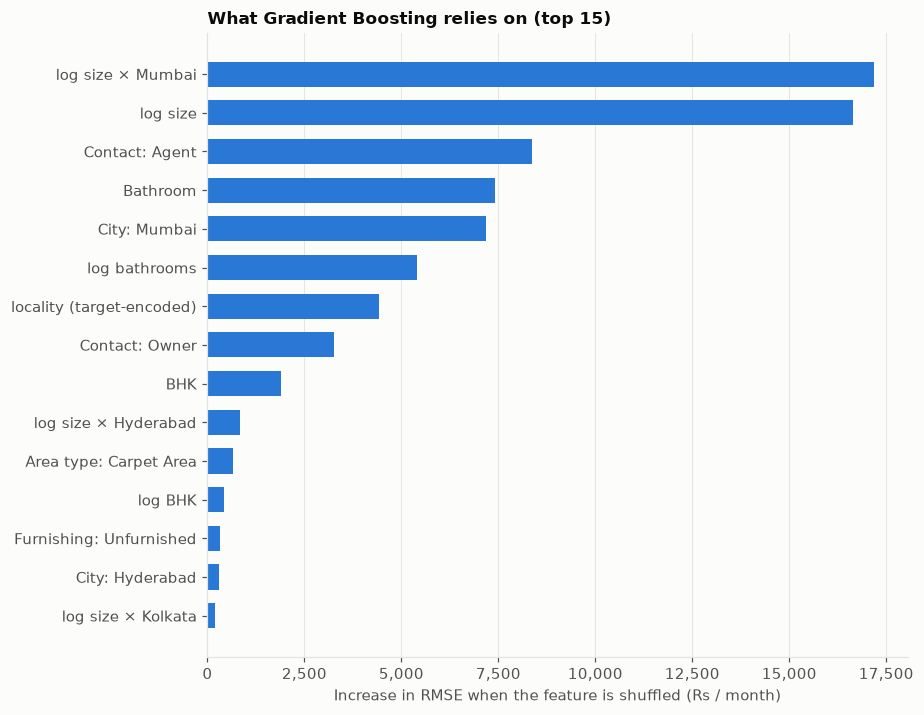

In [3]:
result = permutation_importance(member['model'], data['X_val'], data['y_val'], n_repeats=10,
                                random_state=config.RANDOM_STATE, scoring='neg_root_mean_squared_error')
importance = pd.Series(result.importances_mean, index=member['feature_names'])
fig = plot_importance(importance, f'What {final.name} relies on (top 15)',
                      'Increase in RMSE when the feature is shuffled (Rs / month)',
                      save_path=config.VIZ_DIR / 'feature_importance.png')
importance.sort_values(ascending=False).head(15).to_frame('RMSE increase (Rs)')

`logsize_x_<city>` is log(size) for listings in that city (zero elsewhere), so it captures the price of space in each
city; `locality_target_enc` is the locality's typical (log) rent, learned inside cross-validation.

Optional — SHAP values for per-listing explanations (`pip install shap`):
```python
import shap
inner = member['model'].regressor_.named_steps['model']
shap.plots.beeswarm(shap.Explainer(inner, data['X_train'])(data['X_val']), max_display=15)
```